In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from scipy.stats import ttest_1samp
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from matplotlib.colors import LinearSegmentedColormap

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A4_DCBC_pairwise', f'{dataset_name}')

In [4]:
ROIs = ['PFC', 'visual', 'somatosensory', 'parietal'] 
n_rois = len(ROIs) 
significance_level = 0.05 

In [5]:
cdict = {'red':   ((0.0, 1.0, 1.0),  # Start at white (R=1)
                   (1.0, 1.0, 1.0)), # End at red (R=1)
         'green': ((0.0, 1.0, 1.0),  # Start at white (G=1)
                   (1.0, 0.0, 0.0)), # End at red (G=0)
         'blue':  ((0.0, 1.0, 1.0),  # Start at white (B=1)
                   (1.0, 0.0, 0.0))} # End at red (B=0)

# Create the colormap
cmap = LinearSegmentedColormap('WhiteToRed', cdict)

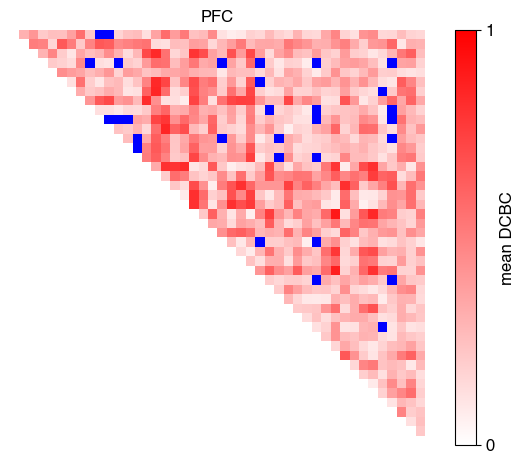

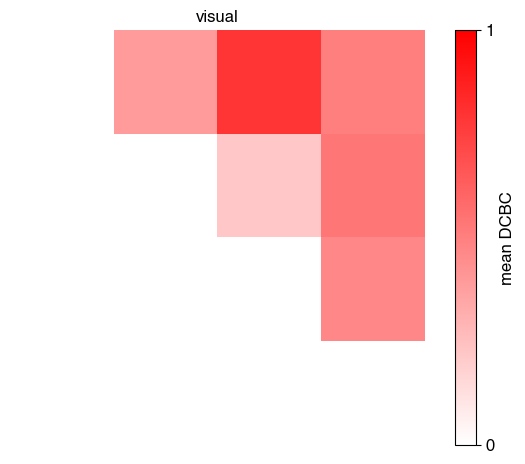

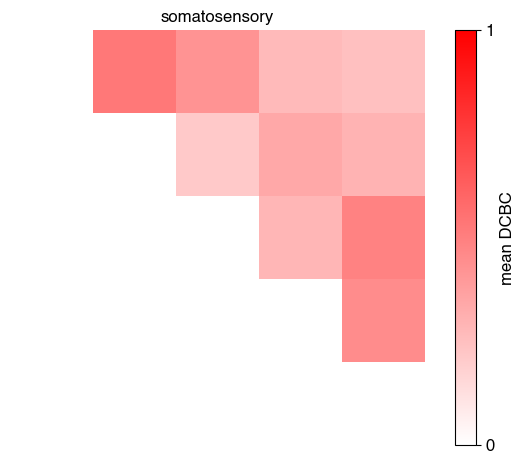

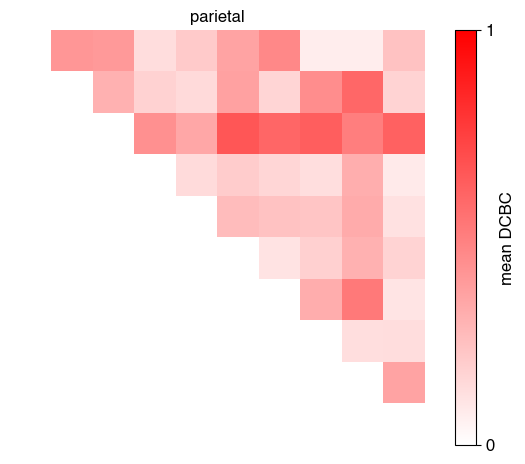

In [6]:
for roiI in np.arange(n_rois):
    PKL_pairwise_dcbc = os.path.join(projectPath, 'results', 'START_A4_DCBC_pairwise', f'{dataset_name}', f'output_{ROIs[roiI]}.pkl')
    with open(PKL_pairwise_dcbc, 'rb') as pf:
        output_pairwise_dcbc = pickle.load(pf)
        dcbc_pairwise = output_pairwise_dcbc['dcbc_pairwise']

    n_subjects, n_parcels, _ = dcbc_pairwise.shape

    pvals_pairwise = np.inf * np.ones((n_parcels, n_parcels)) 
    dcbc_pairwise[np.logical_or(dcbc_pairwise==np.inf, dcbc_pairwise==-np.inf)] = np.nan 

    for i in np.arange(n_parcels-1):
        for j in np.arange(i+1, n_parcels):
            dcbcs = dcbc_pairwise[:, i, j]            
            ttest_result = ttest_1samp(dcbcs, 0, alternative='greater', nan_policy='omit')
            pvals_pairwise[i, j] = ttest_result.pvalue 
    
    dcbc_pairwise_mean = np.nanmean(dcbc_pairwise, axis=0) 
    dcbc_pairwise_mean[np.logical_and(pvals_pairwise>0.05, pvals_pairwise<np.inf)] = -1 
   
    fig, ax = plt.subplots() 
    im = ax.imshow(dcbc_pairwise_mean, cmap=cmap, vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f'{ROIs[roiI]}', fontsize=12) 
    im.cmap.set_under('blue') 
    cbar = plt.colorbar(im, ticks=[0, 1], ax=ax)  
    cbar.set_label('mean DCBC', fontsize=12)

    plt.tight_layout() 

    JPG_fig = os.path.join(resultsPath, f'mean_pairwise_dcbc_{ROIs[roiI]}.jpg')
    plt.savefig(JPG_fig, dpi=500, format='jpg')

In [7]:
df = pd.DataFrame(pvals_pairwise)
display(df)

,0,1,2,3,4,5,6,7,8,9
0,inf,6.881993e-12,6.487689e-12,1.183374e-08,1.336510e-06,1.689266e-10,5.135912e-12,1.491645e-04,5.903290e-07,1.298308e-09
1,inf,inf,1.656037e-08,3.876971e-07,1.003017e-07,2.491914e-10,8.058691e-08,4.939124e-10,5.585045e-13,1.076650e-07
2,inf,inf,inf,1.015273e-10,4.412489e-08,1.576008e-11,1.310046e-10,5.116054e-11,5.657498e-11,1.825557e-10
3,inf,inf,inf,inf,7.531430e-07,3.628791e-10,3.366616e-09,1.378074e-06,3.055008e-11,4.019928e-07
4,inf,inf,inf,inf,inf,1.046876e-10,7.938922e-09,4.205784e-08,1.549355e-08,1.306303e-06
5,inf,inf,inf,inf,inf,inf,3.652748e-06,1.453537e-08,4.410181e-12,2.101417e-07
6,inf,inf,inf,inf,inf,inf,inf,3.097753e-10,5.141569e-13,4.356342e-05
7,inf,inf,inf,inf,inf,inf,inf,inf,9.808841e-09,3.327046e-10
8,inf,inf,inf,inf,inf,inf,inf,inf,inf,4.728849e-12
9,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
